In [1]:
!pip install -q kaggle imbalanced-learn xgboost shap

In [2]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shubhi58singh","key":"314b80ab1d60c0b26e134bdfc17c0078"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets list -s "credit card fraud"

ref                                                        title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
mlg-ulb/creditcardfraud                                    Credit Card Fraud Detection                         69155672  2018-03-23 01:17:27.913000        1193757      13483  0.85294116       
dhanushnarayananr/credit-card-fraud                        Credit Card Fraud                                   30281243  2022-05-07 15:09:29.617000          33156        249  0.9411765        
joebeachcapital/credit-card-fraud                          Credit Card Fraud                                  223011632  2023-08-07 02:16:37.627000           5352         82  1                
mishra5001/credit-card             

In [5]:
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:03<00:00, 19.1MB/s]



In [6]:
!unzip -o creditcardfraud.zip

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [7]:
import os

os.listdir()

['.config',
 'kaggle.json',
 'creditcardfraud.zip',
 'creditcard.csv',
 'sample_data']

In [8]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

In [9]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
df.shape

(284807, 31)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [12]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [13]:
df["Class"].value_counts()
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


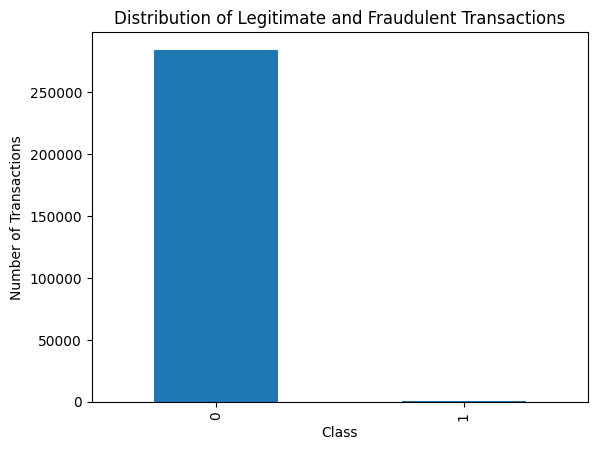

In [14]:
import matplotlib.pyplot as plt

df["Class"].value_counts().plot(kind="bar")

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.show()

In [15]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [16]:
df.isnull().sum().sum()

np.int64(0)

In [17]:
df.duplicated().sum()

np.int64(1081)

In [18]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [19]:
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


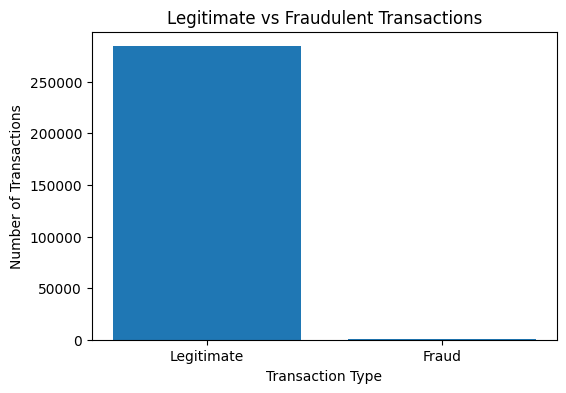

In [20]:
import matplotlib.pyplot as plt

class_counts = df["Class"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Legitimate", "Fraud"], class_counts.values)

plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

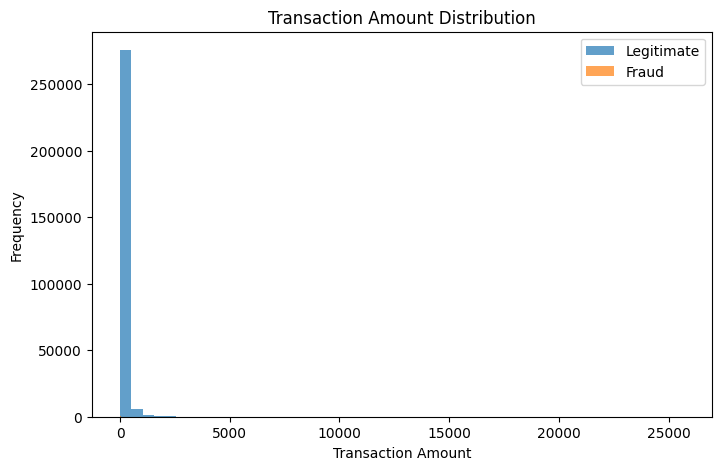

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(df[df["Class"] == 0]["Amount"], bins=50, alpha=0.7, label="Legitimate")
plt.hist(df[df["Class"] == 1]["Amount"], bins=50, alpha=0.7, label="Fraud")

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution")
plt.legend()

plt.show()

In [22]:
df.groupby("Class")["Amount"].agg(["count", "mean", "median", "std", "min", "max"])

,count,mean,median,std,min,max
Class,,,,,,
0,284315,88.291022,22.00,250.105092,0.0,25691.16
1,492,122.211321,9.25,256.683288,0.0,2125.87


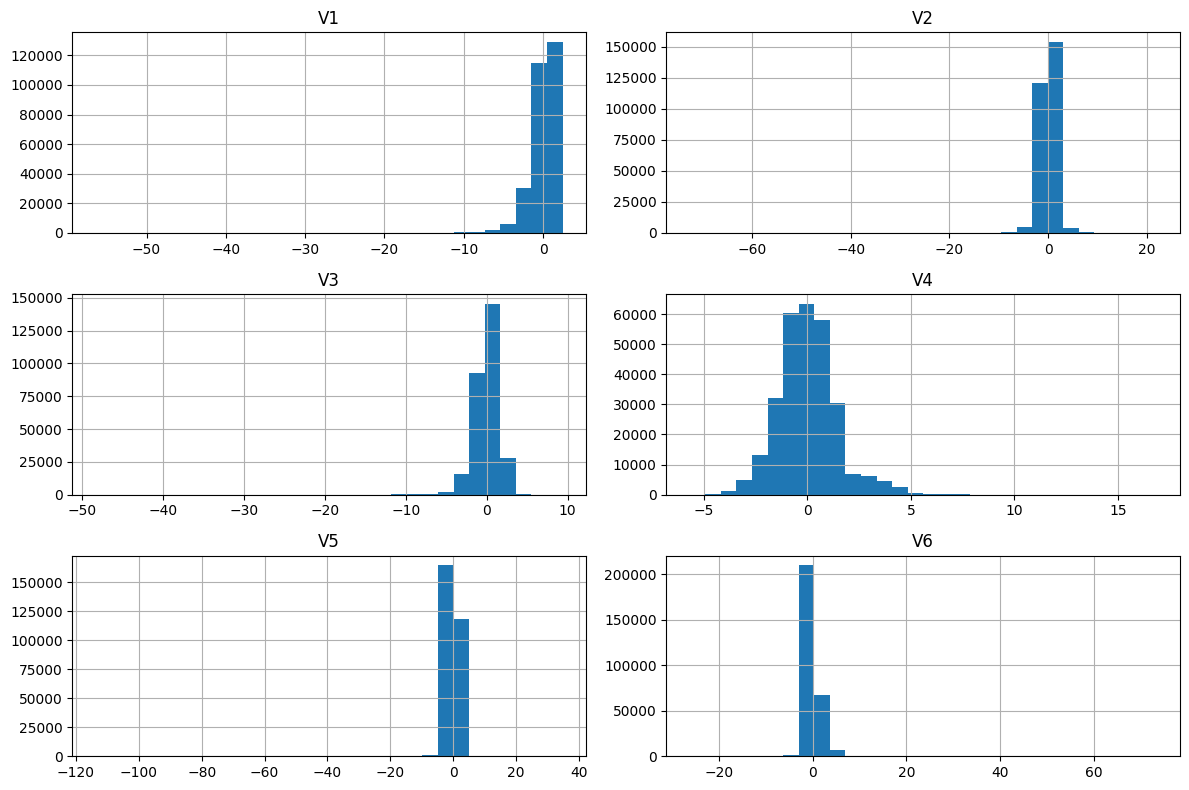

In [23]:
features = ["V1", "V2", "V3", "V4", "V5", "V6"]

df[features].hist(figsize=(12, 8), bins=30)

plt.tight_layout()
plt.show()

In [24]:
correlation = df.corr()["Class"].sort_values()

correlation

,Class
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V18,-0.111485
V1,-0.101347
V9,-0.097733


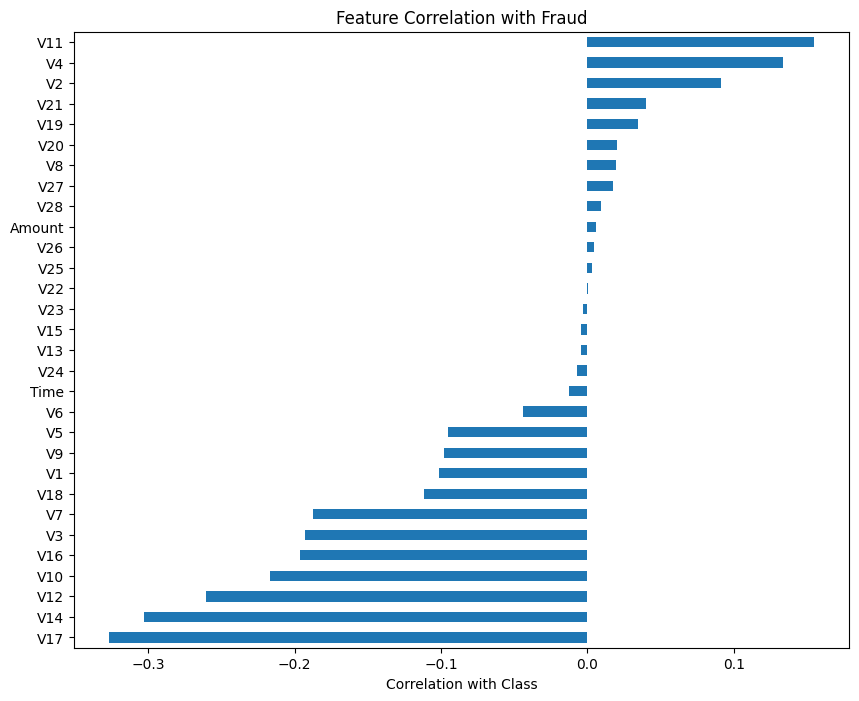

In [25]:
plt.figure(figsize=(10, 8))

correlation.drop("Class").sort_values().plot(kind="barh")

plt.title("Feature Correlation with Fraud")
plt.xlabel("Correlation with Class")

plt.show()

In [26]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [27]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
print("Training set:")
print(y_train.value_counts())

print("\nTesting set:")
print(y_test.value_counts())

Training set:
Class
0    227451
1       394
Name: count, dtype: int64

Testing set:
Class
0    56864
1       98
Name: count, dtype: int64


In [30]:
# Remove duplicate transactions
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the new distribution
print("\nTraining set:")
print(y_train.value_counts())

print("\nTesting set:")
print(y_test.value_counts())

Dataset shape after removing duplicates: (283726, 31)

Training set:
Class
0    226602
1       378
Name: count, dtype: int64

Testing set:
Class
0    56651
1       95
Name: count, dtype: int64


In [31]:
from imblearn.over_sampling import SMOTE

In [32]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64


In [33]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [34]:
print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


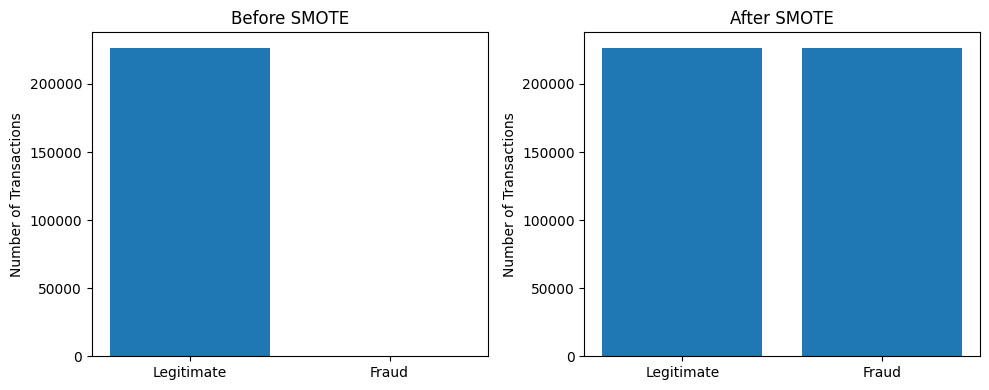

In [35]:
import matplotlib.pyplot as plt

before = y_train.value_counts()
after = y_train_smote.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
axes[0].bar(["Legitimate", "Fraud"], before.values)
axes[0].set_title("Before SMOTE")
axes[0].set_ylabel("Number of Transactions")

# After SMOTE
axes[1].bar(["Legitimate", "Fraud"], after.values)
axes[1].set_title("After SMOTE")
axes[1].set_ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [36]:
from xgboost import XGBClassifier

In [37]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

In [38]:
model.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [39]:
y_prob = model.predict_proba(X_test)[:, 1]

In [40]:
y_pred = (y_prob >= 0.5).astype(int)

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.81      0.80      0.80        95

    accuracy                           1.00     56746
   macro avg       0.90      0.90      0.90     56746
weighted avg       1.00      1.00      1.00     56746



[[56633    18]
 [   19    76]]


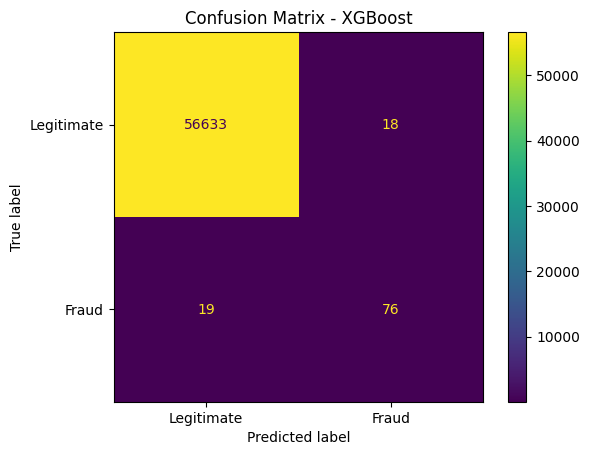

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9993479716632009
Precision: 0.8085106382978723
Recall   : 0.8
F1 Score : 0.8042328042328042


In [44]:
y_prob = model.predict_proba(X_test)[:, 1]

In [45]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 1.0, 0.05)

results = []

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

In [46]:
threshold_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.481481,0.821053,0.607004
1,0.15,0.550725,0.800000,0.652361
2,0.20,0.617886,0.800000,0.697248
3,0.25,0.660870,0.800000,0.723810
4,0.30,0.678571,0.800000,0.734300
5,0.35,0.710280,0.800000,0.752475
6,0.40,0.745098,0.800000,0.771574
7,0.45,0.791667,0.800000,0.795812
8,0.50,0.808511,0.800000,0.804233
9,0.55,0.844444,0.800000,0.821622


In [47]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print(best_row)

Threshold    0.850000
Precision    0.915663
Recall       0.800000
F1           0.853933
Name: 15, dtype: float64


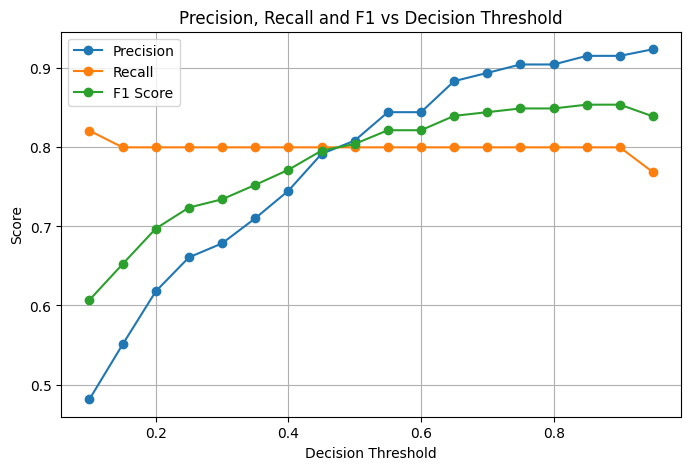

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Decision Threshold")
plt.legend()
plt.grid(True)

plt.show()

In [49]:
high_recall = threshold_df[
    threshold_df["Recall"] >= 0.90
]

high_recall

,Threshold,Precision,Recall,F1


In [50]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.01,0.153409,0.852632,0.260032
1,0.02,0.223140,0.852632,0.353712
2,0.03,0.272727,0.852632,0.413265
3,0.04,0.320000,0.842105,0.463768
4,0.05,0.355556,0.842105,0.500000
...,...,...,...,...
94,0.95,0.924051,0.768421,0.839080
95,0.96,0.935897,0.768421,0.843931
96,0.97,0.948052,0.768421,0.848837
97,0.98,0.948052,0.768421,0.848837


In [51]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("Best threshold based on F1:")
print(best_row)

Best threshold based on F1:
Threshold    0.810000
Precision    0.915663
Recall       0.800000
F1           0.853933
Name: 80, dtype: float64


In [52]:
max_recall_row = threshold_df.loc[
    threshold_df["Recall"].idxmax()
]

print("Maximum recall:")
print(max_recall_row)


Maximum recall:
Threshold    0.010000
Precision    0.153409
Recall       0.852632
F1           0.260032
Name: 0, dtype: float64


In [53]:
high_recall = threshold_df[
    threshold_df["Recall"] >= 0.90
]

if len(high_recall) > 0:

    best_high_recall = high_recall.loc[
        high_recall["F1"].idxmax()
    ]

    print("Best threshold with recall >= 90%:")
    print(best_high_recall)

else:

    print("No threshold achieved 90% recall.")
    print("Maximum recall achieved:",
          threshold_df["Recall"].max())

No threshold achieved 90% recall.
Maximum recall achieved: 0.8526315789473684


In [54]:
threshold_df.sort_values(
    "F1",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
85,0.86,0.915663,0.8,0.853933
84,0.85,0.915663,0.8,0.853933
83,0.84,0.915663,0.8,0.853933
88,0.89,0.915663,0.8,0.853933
89,0.90,0.915663,0.8,0.853933
81,0.82,0.915663,0.8,0.853933
87,0.88,0.915663,0.8,0.853933
86,0.87,0.915663,0.8,0.853933
80,0.81,0.915663,0.8,0.853933
82,0.83,0.915663,0.8,0.853933


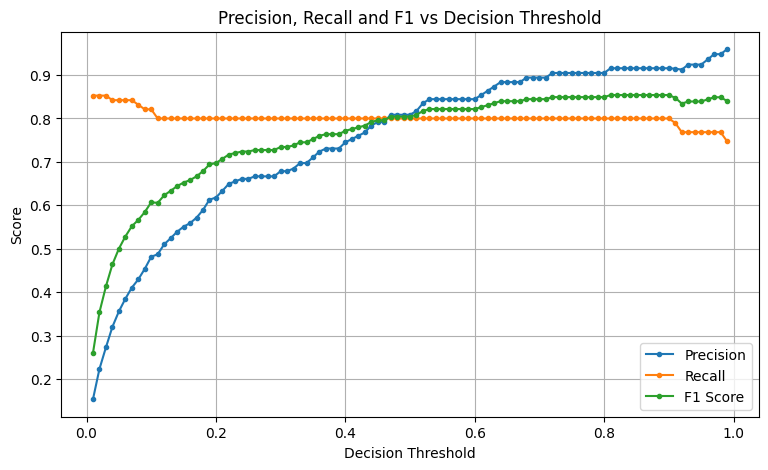

In [55]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    markersize=3,
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    markersize=3,
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    markersize=3,
    label="F1 Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Decision Threshold")
plt.legend()
plt.grid(True)

plt.show()

In [56]:
print("Best F1:")
print(best_row)

print("\nMaximum recall:")
print(max_recall_row)

print("\nBest high-recall threshold:")
if len(high_recall) > 0:
    print(best_high_recall)
else:
    print("No threshold achieved 90% recall")

Best F1:
Threshold    0.810000
Precision    0.915663
Recall       0.800000
F1           0.853933
Name: 80, dtype: float64

Maximum recall:
Threshold    0.010000
Precision    0.153409
Recall       0.852632
F1           0.260032
Name: 0, dtype: float64

Best high-recall threshold:
No threshold achieved 90% recall


In [57]:
selected_thresholds = [0.01, 0.50, 0.81]

comparison = []

for threshold in selected_thresholds:

    predictions = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    comparison.append([
        threshold,
        precision,
        recall,
        f1
    ])

comparison_df = pd.DataFrame(
    comparison,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

comparison_df

,Threshold,Precision,Recall,F1
0,0.01,0.153409,0.852632,0.260032
1,0.50,0.808511,0.800000,0.804233
2,0.81,0.915663,0.800000,0.853933


In [58]:
final_threshold = 0.81

y_pred_final = (y_prob >= final_threshold).astype(int)

cm_final = confusion_matrix(y_test, y_pred_final)

print(cm_final)

[[56644     7]
 [   19    76]]


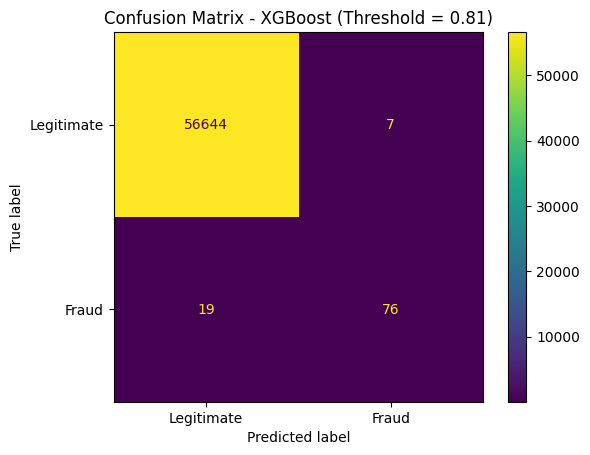

In [59]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()
plt.title("Confusion Matrix - XGBoost (Threshold = 0.81)")
plt.show()

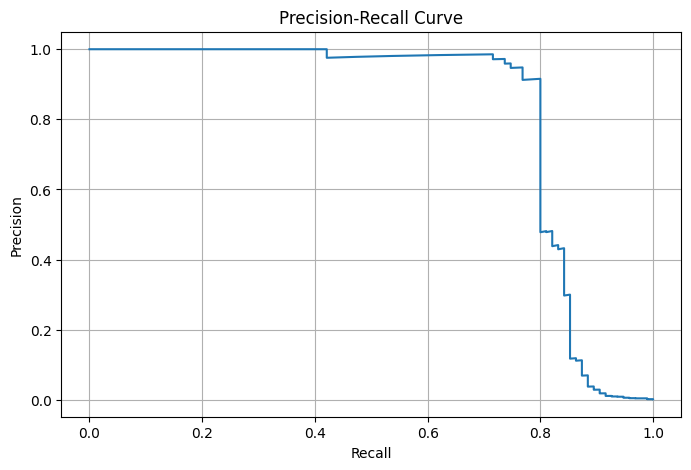

In [60]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds_pr = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 5))

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)

plt.show()

In [61]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
14,V14,0.664284
10,V10,0.061762
12,V12,0.040782
4,V4,0.040450
17,V17,0.024945
8,V8,0.013687
3,V3,0.012683
11,V11,0.012487
1,V1,0.012470
9,V9,0.008904


In [62]:
top_features = feature_importance.head(15)

top_features

,Feature,Importance
14,V14,0.664284
10,V10,0.061762
12,V12,0.040782
4,V4,0.040450
17,V17,0.024945
8,V8,0.013687
3,V3,0.012683
11,V11,0.012487
1,V1,0.012470
9,V9,0.008904


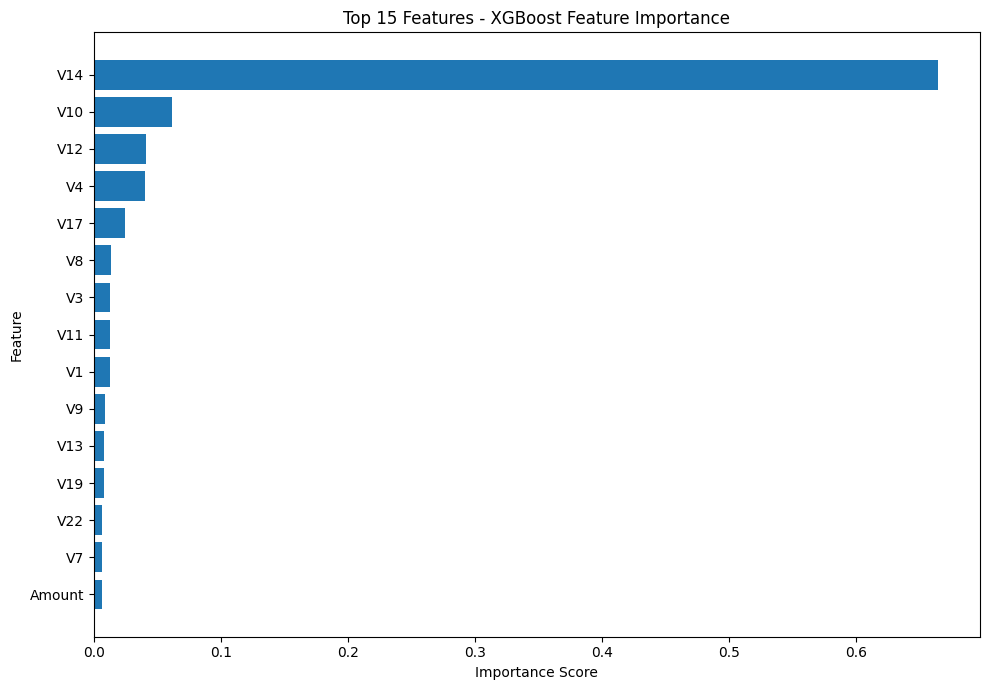

In [63]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 15 Features - XGBoost Feature Importance")

plt.tight_layout()
plt.show()

In [64]:
print("Top 15 Important Features:\n")

for i, row in top_features.reset_index(drop=True).iterrows():
    print(
        f"{i+1}. {row['Feature']} "
        f"-> {row['Importance']:.4f}"
    )

Top 15 Important Features:

1. V14 -> 0.6643
2. V10 -> 0.0618
3. V12 -> 0.0408
4. V4 -> 0.0405
5. V17 -> 0.0249
6. V8 -> 0.0137
7. V3 -> 0.0127
8. V11 -> 0.0125
9. V1 -> 0.0125
10. V9 -> 0.0089
11. V13 -> 0.0082
12. V19 -> 0.0077
13. V22 -> 0.0065
14. V7 -> 0.0063
15. Amount -> 0.0062


In [65]:
import shap

explainer = shap.TreeExplainer(model)


In [66]:
X_shap = X_test.sample(
    n=min(5000, len(X_test)),
    random_state=42
)

In [67]:
shap_values = explainer.shap_values(X_shap)

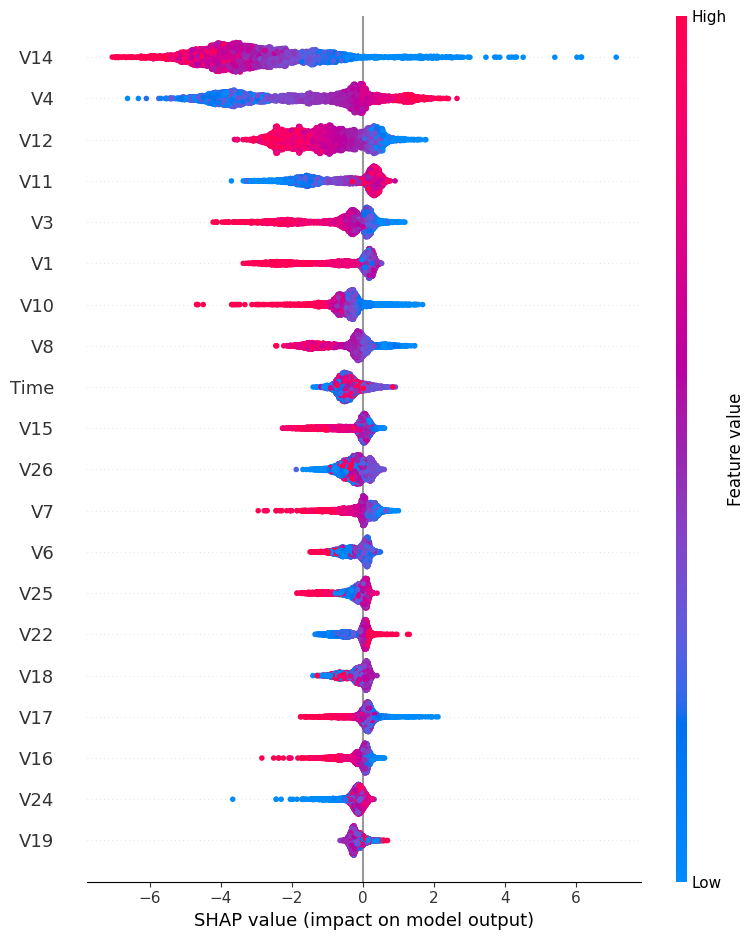

In [68]:
shap.summary_plot(
    shap_values,
    X_shap,
    show=True
)

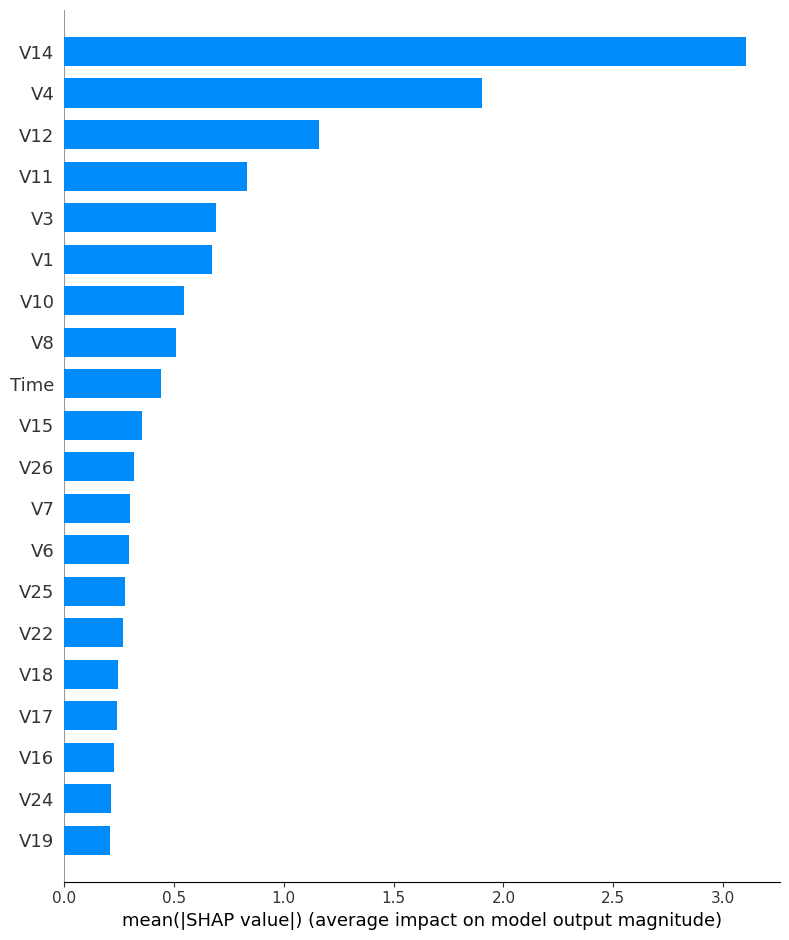

In [69]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=True
)

In [70]:
fraud_indices = np.where(y_pred_final == 1)[0]

print("Number of transactions predicted as fraud:",
      len(fraud_indices))

Number of transactions predicted as fraud: 83


In [71]:
fraud_index = fraud_indices[0]

transaction = X_test.iloc[[fraud_index]]

print(transaction)

           Time        V1        V2        V3        V4        V5        V6  \
116139  74159.0 -1.548788  1.808698 -0.953509  2.213085 -2.015728 -0.913457   

              V7        V8        V9  ...       V20       V21       V22  \
116139 -2.356013  1.197169 -1.678374  ...  0.390786  0.855138  0.774745   

             V23     V24       V25       V26       V27       V28  Amount  
116139  0.059037  0.3432 -0.468938 -0.278338  0.625922  0.395573   76.94  

[1 rows x 30 columns]


In [72]:
transaction_shap = explainer.shap_values(transaction)

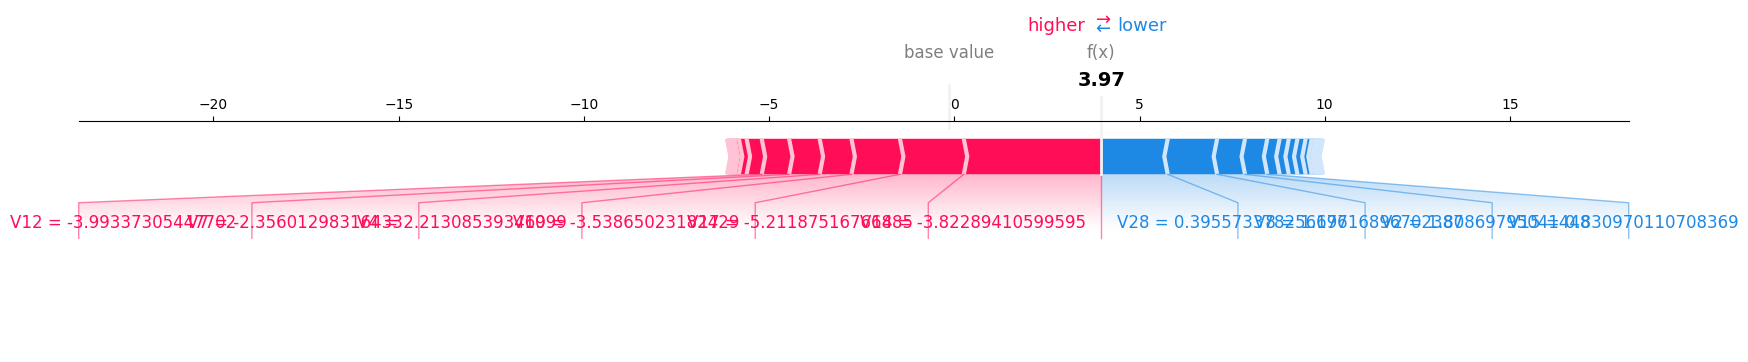

In [73]:
shap.force_plot(
    explainer.expected_value,
    transaction_shap[0],
    transaction.iloc[0],
    matplotlib=True
)

In [74]:
print("Transaction index:", X_test.index[fraud_index])

print("Actual class:",
      y_test.iloc[fraud_index])

print("Fraud probability:",
      y_prob[fraud_index])

print("Predicted class:",
      y_pred_final[fraud_index])

Transaction index: 116139
Actual class: 1
Fraud probability: 0.9814813
Predicted class: 1


In [75]:
shap_transaction = pd.DataFrame({
    "Feature": X_shap.columns,
    "SHAP_Value": transaction_shap[0],
    "Feature_Value": transaction.iloc[0].values
})

shap_transaction["Absolute_SHAP"] = (
    shap_transaction["SHAP_Value"].abs()
)

shap_transaction = shap_transaction.sort_values(
    "Absolute_SHAP",
    ascending=False
)

shap_transaction.head(10)

,Feature,SHAP_Value,Feature_Value,Absolute_SHAP
14,V14,3.714327,-3.822894,3.714327
28,V28,-1.791638,0.395573,1.791638
17,V17,1.723474,-5.211875,1.723474
8,V8,-1.332904,1.197169,1.332904
10,V10,1.309130,-3.538650,1.309130
4,V4,0.858540,2.213085,0.858540
7,V7,0.825012,-2.356013,0.825012
2,V2,-0.752784,1.808698,0.752784
12,V12,0.738598,-3.993373,0.738598
15,V15,-0.602042,0.830970,0.602042


In [76]:
shap_transaction[
    shap_transaction["SHAP_Value"] > 0
].head(10)

,Feature,SHAP_Value,Feature_Value,Absolute_SHAP
14,V14,3.714327,-3.822894,3.714327
17,V17,1.723474,-5.211875,1.723474
10,V10,1.309130,-3.538650,1.309130
4,V4,0.858540,2.213085,0.858540
7,V7,0.825012,-2.356013,0.825012
12,V12,0.738598,-3.993373,0.738598
16,V16,0.408317,-2.475359,0.408317
1,V1,0.208647,-1.548788,0.208647
21,V21,0.114554,0.855138,0.114554
29,Amount,0.094291,76.940000,0.094291


In [77]:
shap_transaction[
    shap_transaction["SHAP_Value"] < 0
].head(10)

,Feature,SHAP_Value,Feature_Value,Absolute_SHAP
28,V28,-1.791638,0.395573,1.791638
8,V8,-1.332904,1.197169,1.332904
2,V2,-0.752784,1.808698,0.752784
15,V15,-0.602042,0.830970,0.602042
25,V25,-0.332347,-0.468938,0.332347
6,V6,-0.248275,-0.913457,0.248275
26,V26,-0.233277,-0.278338,0.233277
19,V19,-0.221497,0.933262,0.221497
0,Time,-0.162538,74159.000000,0.162538
5,V5,-0.103874,-2.015728,0.103874


In [78]:
final_threshold = 0.81

y_pred_final = (
    y_prob >= final_threshold
).astype(int)

In [79]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Final Model Performance")
print("-----------------------")

print("Threshold :", final_threshold)

print("Accuracy  :", accuracy_score(y_test, y_pred_final))

print("Precision :", precision_score(y_test, y_pred_final))

print("Recall    :", recall_score(y_test, y_pred_final))

print("F1 Score  :", f1_score(y_test, y_pred_final))

print("ROC-AUC   :", roc_auc_score(y_test, y_prob))

print("PR-AUC    :", average_precision_score(y_test, y_prob))

Final Model Performance
-----------------------
Threshold : 0.81
Accuracy  : 0.9995418179254926
Precision : 0.9156626506024096
Recall    : 0.8
F1 Score  : 0.8539325842696629
ROC-AUC   : 0.9683800815519584
PR-AUC    : 0.8168572787099628


In [80]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Score": [
        accuracy_score(y_test, y_pred_final),
        precision_score(y_test, y_pred_final),
        recall_score(y_test, y_pred_final),
        f1_score(y_test, y_pred_final),
        roc_auc_score(y_test, y_prob),
        average_precision_score(y_test, y_prob)
    ]
})

final_results["Score"] = (
    final_results["Score"] * 100
).round(2)

final_results

,Metric,Score
0,Accuracy,99.95
1,Precision,91.57
2,Recall,80.00
3,F1 Score,85.39
4,ROC-AUC,96.84
5,PR-AUC,81.69


In [81]:
threshold_comparison = comparison_df.copy()

threshold_comparison["Precision"] = (
    threshold_comparison["Precision"] * 100
).round(2)

threshold_comparison["Recall"] = (
    threshold_comparison["Recall"] * 100
).round(2)

threshold_comparison["F1"] = (
    threshold_comparison["F1"] * 100
).round(2)

threshold_comparison

,Threshold,Precision,Recall,F1
0,0.01,15.34,85.26,26.00
1,0.50,80.85,80.00,80.42
2,0.81,91.57,80.00,85.39


In [82]:
model_no_smote = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

model_no_smote.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [83]:
model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [84]:
model_no_smote.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [85]:
y_prob_no_smote = model_no_smote.predict_proba(X_test)[:, 1]

In [86]:
y_pred_no_smote = (
    y_prob_no_smote >= 0.5
).astype(int)

In [87]:
print("XGBoost WITHOUT SMOTE")
print("---------------------")

print("Accuracy  :", accuracy_score(y_test, y_pred_no_smote))
print("Precision :", precision_score(y_test, y_pred_no_smote, zero_division=0))
print("Recall    :", recall_score(y_test, y_pred_no_smote, zero_division=0))
print("F1 Score  :", f1_score(y_test, y_pred_no_smote, zero_division=0))
print("ROC-AUC   :", roc_auc_score(y_test, y_prob_no_smote))
print("PR-AUC    :", average_precision_score(y_test, y_prob_no_smote))

XGBoost WITHOUT SMOTE
---------------------
Accuracy  : 0.9994889507630493
Precision : 0.9459459459459459
Recall    : 0.7368421052631579
F1 Score  : 0.8284023668639053
ROC-AUC   : 0.9756373511314429
PR-AUC    : 0.8078943694637063


[[56647     4]
 [   25    70]]


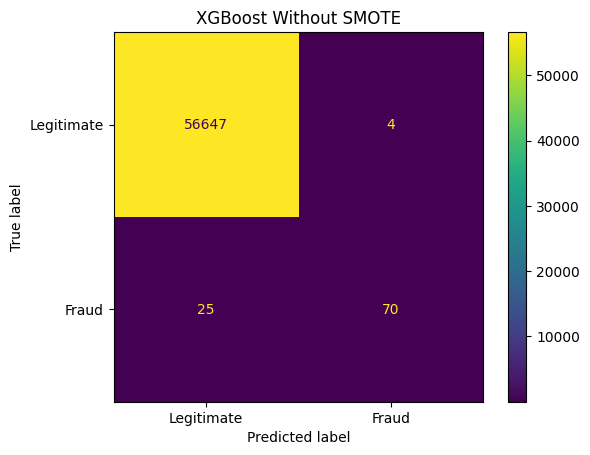

In [88]:
cm_no_smote = confusion_matrix(
    y_test,
    y_pred_no_smote
)

print(cm_no_smote)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_no_smote,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title("XGBoost Without SMOTE")
plt.show()

In [89]:
comparison_models = pd.DataFrame({
    "Model": [
        "XGBoost + SMOTE",
        "XGBoost without SMOTE"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_final),
        accuracy_score(y_test, y_pred_no_smote)
    ],
    "Precision": [
        precision_score(y_test, y_pred_final),
        precision_score(y_test, y_pred_no_smote)
    ],
    "Recall": [
        recall_score(y_test, y_pred_final),
        recall_score(y_test, y_pred_no_smote)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_final),
        f1_score(y_test, y_pred_no_smote)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_no_smote)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, y_prob_no_smote)
    ]
})

comparison_models.iloc[:, 1:] = (
    comparison_models.iloc[:, 1:] * 100
).round(2)

comparison_models

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost + SMOTE,99.95,91.57,80.00,85.39,96.84,81.69
1,XGBoost without SMOTE,99.95,94.59,73.68,82.84,97.56,80.79


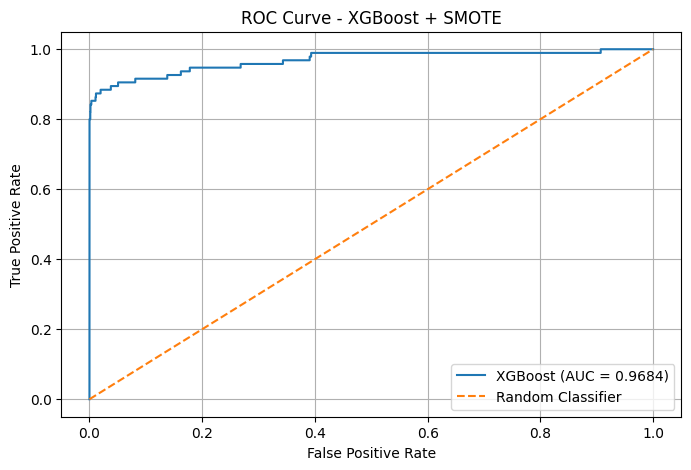

In [90]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost + SMOTE")
plt.legend()
plt.grid(True)

plt.show()